In [ ]:
import os
os.chdir(Insert Project Path)

## Notebook 4: Feature engineering
This notebook was used to prepare features for the risk scoring, and later for anomaly detection. It was clear to me that the analytical priority of an asteroid should depend on its size, velocity, and distance from the Earth. Obviously, larger asteroids can be extremely destructive, fast asteroids also, and the distance from the Earth decides the probability of an asteroid colliding with the planet. Therefore, I wanted features that represented each of these characteristics.

In [2]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading SQL into pandas df
with sqlite3.connect("data/nasa_asteroids.db") as c:

    df = pd.read_sql_query("""
        SELECT *
        FROM close_approaches
        """, c
    )

In [4]:
#converting dates again
df["close_approach_date"] = pd.to_datetime(
    df["close_approach_date"]
)

df["close_approach_date_full"] = pd.to_datetime(
    df["close_approach_date_full"],
    format="mixed"
)

As the minimum and maximum diameter basically provided the same information, I wanted to get a mean value, and a range. The mean diameter represented the size of the asteroid, with the range depicting the uncertainty in the size. 

In [6]:
#new features, diameter mean and range to get meaingful features
#high range means more uncertainty -> may mean more risk, might be useful
df["diameter_mean_km"] = (df["diameter_min_km"]+df["diameter_max_km"]) / 2
df["diameter_range_km"] = df["diameter_max_km"] - df["diameter_min_km"]
df[["diameter_min_km", "diameter_max_km", "diameter_mean_km", "diameter_range_km"]].describe()


,diameter_min_km,diameter_max_km,diameter_mean_km,diameter_range_km
count,14471.000000,14471.000000,14471.000000,14471.000000
mean,0.112174,0.250828,0.181501,0.138655
std,0.253890,0.567715,0.410802,0.313825
min,0.000818,0.001828,0.001323,0.001011
25%,0.019704,0.044060,0.031882,0.024356
50%,0.048368,0.108153,0.078260,0.059786
75%,0.138853,0.310485,0.224669,0.171632
max,22.108281,49.435619,35.771950,27.327338


Then, I log transformed the mean in order to get a feature distributed normally.

In [7]:
#log transforming the mean as discussed
df["log_diameter_mean_km"] = np.log(df["diameter_mean_km"])
print(df["log_diameter_mean_km"].skew())
df["log_diameter_mean_km"].describe().T

0.039061995829351076


count    14471.000000
mean        -2.489529
std          1.274504
min         -6.627893
25%         -3.445720
50%         -2.547712
75%         -1.493128
max          3.577164
Name: log_diameter_mean_km, dtype: float64

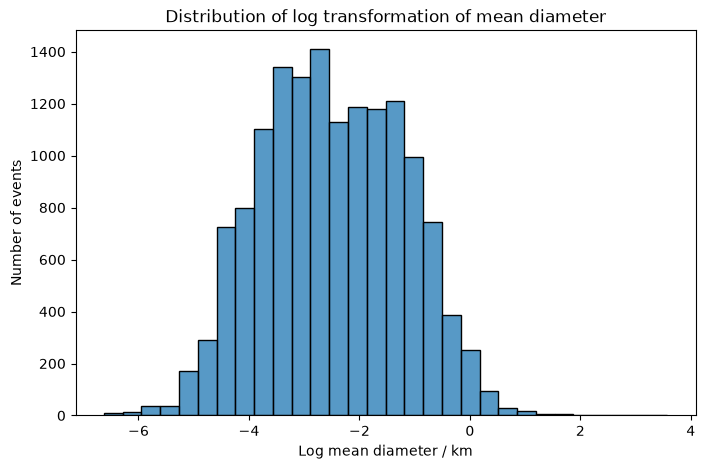

In [8]:
#visualise new feature
plt.figure(figsize=(8,5))
sns.histplot(data=df, x = "log_diameter_mean_km", bins=30)
plt.title("Distribution of log transformation of mean diameter")
plt.xlabel("Log mean diameter / km")
plt.ylabel("Number of events")
plt.show()


It was evident that this new feature would be more suitable for our risk score. Before, it would be incredibly hard to distinguish between asteroids in the lower tail. However, I will want to keep the original data also, as this will be useful for detecting anomalies due to the skewness.

Also, I wanted to verify the mathematics between absolute magnitude and the log of the diameter's mean. This showed that the two were inversely proportional and essentially provide the same information, and so only one of the two would be needed to calculate the risk score.

In [ ]:
#nasa states the two are linearly related
df[["absolute_magnitude_h", "log_diameter_mean_km"]].corr()

,absolute_magnitude_h,log_diameter_mean_km
absolute_magnitude_h,1.0,-1.0
log_diameter_mean_km,-1.0,1.0


I also wanted to try a log transform on relative velocity, as it possessed moderate right-skew. However, this only made the distribution more asymmetric so I discarded the idea.

In [ ]:
#want to try log on velocity too as it was skewed
df["log_relative_velocity_km_s"] = np.log(df["relative_velocity_km_s"])
print(df["log_relative_velocity_km_s"].skew())
print(df["relative_velocity_km_s"].skew())
df = df.drop(columns = ["log_relative_velocity_km_s"])

-0.7540578883588794
0.800504034816047


Now, I was left with three variables that represented the characteristics I wanted to affect an asteroid's risk score in this project. 

Size: log mean of diameter \
Velocity: relative velocity (km/s) \
Distance: miss distance (AU)

In [ ]:
risk_features_df = df[["log_diameter_mean_km", "relative_velocity_km_s", "miss_distance_au"]].copy()
risk_features_df.describe().T 

,count,mean,std,min,25%,50%,75%,max
log_diameter_mean_km,14471.0,-2.489529,1.274504,-6.627893,-3.445720,-2.547712,-1.493128,3.577164
relative_velocity_km_s,14471.0,13.735364,6.968060,0.080168,8.321646,12.908385,18.029074,57.546852
miss_distance_au,14471.0,0.263333,0.140451,0.000105,0.145061,0.263754,0.386790,0.499952


Obviously, I could not simply add the three variables, as velocity would dominate the scoring: I needed to standardise the data. I mapped the data onto the interval $[0,1]$ using different methods for each

In [ ]:
risk_features_df.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

,log_diameter_mean_km,relative_velocity_km_s,miss_distance_au
0.00,-6.627893,0.080168,0.000105
0.25,-3.445720,8.321646,0.145061
0.50,-2.547712,12.908385,0.263754
0.75,-1.493128,18.029074,0.386790
0.90,-0.816168,22.951192,0.456008
0.95,-0.452360,26.472371,0.477742
0.99,0.215390,33.821939,0.495316
1.00,3.577164,57.546852,0.499952


### VELOCITY
Velocity impacts how devastating the impact is, so it is suitable to use a quadratic to map it to our domain as the kinetic energy is $E=\frac{1}{2}mc^2$, so velocity has a quadratic relationship with kinetic energy.

I used 

$$ 
R_{\text{vel}}(v) = \text{min}((\frac{v}{v_{\text{ref}}})^2,1)
$$

60 km/s is the reference velocity used to scale the observed velocity range, chosen as a rounded value slightly above the maximum velocity in the historical dataset. If an asteroid has a relative velocity greater than 60 km/s, it will have a velocity risk component of 1.

### DISTANCE 
Distance appears evenly distributed across the quartiles. As the nasa data is capped at 0.5 AU, all observations have a miss distance in the range of 0.0 to 0.5 AU. 

I didn't have scientific justification for an exact relationship with distance and risk, but I wanted to favour close encounters in the risk score, whilst adhering to the distribution.

Thus it was suitable to use

$$
R_{\text{dis}}(m) = 1-\frac{m}{0.5}
$$

So closer encounters matter more, but recall the distribution of miss distance is roughly uniform.

### SIZE
Mapping this was more complicated, as log mean diameter was not skewed, but contained extreme large outliers. I chose a sigmoid function as it allows the score to reflect how large an asteroid is relative to the size of the observed population. Additionally, it retains the large "jump" we see from the 99th percentile to the maximum value in the dataset, and allows for infinitely large asteroids to be attributed a size risk component. 

I would not want all asteroids with meaningful size to have no risk attached to them purely because of one large, extreme outlier. However, this large outlier would have to be scored much more highly.

So the function was

$$
R_{\text{size}}(d) = \frac{1}{1+e^{-z}}
$$
where 
$$
z = \frac{log(d)-\mu}{\sigma}
$$